In [91]:
# Packages

import os 

import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

In [92]:
# using assert to check that paths exist on computer.
assert os.path.isdir('Data/')

# print everything in Data
os.listdir('Data/')

['Decilgennemsnit.xlsx', 'IFOR41_Hele_Landet.xlsx']

# 1.1 The Gini coefficient and the top 10 percent share

Opening the IFOR41 dataset from Statistics Denmark, which contains Gini coefficient data for the whole of Denmark over time. After importing the file, we clean the data by removing unnecessary rows and columns and assigning clear column names.

In [93]:
# Opening the files

GiniDenmark = os.path.join('Data/', 'IFOR41_Hele_Landet.xlsx')

pd.read_excel(GiniDenmark).iloc[0:,0:]

# Clean up, removing unnessesary rows and columns
GiniDenmark = pd.read_excel(GiniDenmark,skiprows=2)
GiniDenmark = GiniDenmark.iloc[:38, 1:]

# Rename columns
GiniDenmark = GiniDenmark.rename(columns={'Unnamed: 1':'Year'})
GiniDenmark = GiniDenmark.rename(columns={'All Denmark':'Gini coefficient, Denmark'})

display(GiniDenmark)


,Year,"Gini coefficient, Denmark"
0,1987.0,22.07
1,1988.0,22.06
2,1989.0,21.93
3,1990.0,22.16
4,1991.0,21.99
5,1992.0,22.34
6,1993.0,22.79
7,1994.0,22.50
8,1995.0,22.41
9,1996.0,22.83


### Producing the figure with the Gini coefficient for all of Denmark over time.

We use the cleaned up dataset (GiniDenmark) to create the Gini coefficient figure

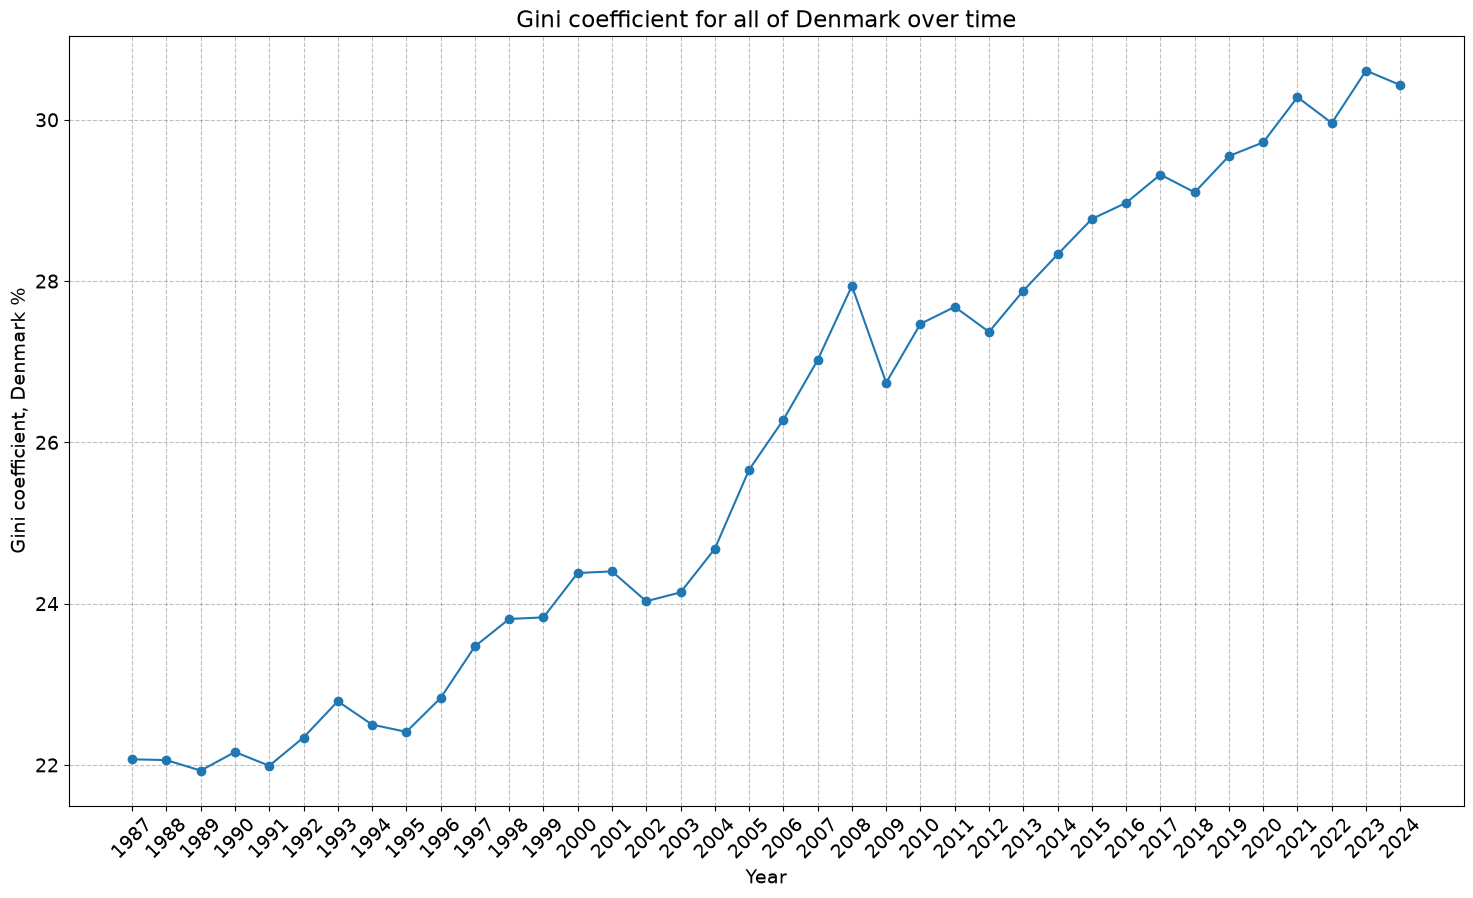

In [122]:
plt.figure(figsize=(18, 10))
plt.plot(GiniDenmark.iloc[:, 0], GiniDenmark.iloc[:, 1], marker='o')
plt.xticks(GiniDenmark.iloc[:, 0][::1], rotation=45)
plt.xlabel("Year")
plt.ylabel("Gini coefficient, Denmark %")
plt.title("Gini coefficient for all of Denmark over time")
plt.grid(True)
plt.show()

### Using table IFOR32, add the share of total income going to the richest 10 percent.

First we import the data containing the average income for each decile group. 

In [103]:
# Opening the files

Deciler = os.path.join('Data/', 'Decilgennemsnit.xlsx')

pd.read_excel(Deciler).iloc[0:,0:]

# Clean up, removing unnessesary rows and columns
Deciler = pd.read_excel(Deciler,skiprows=2)
Deciler = Deciler.drop(Deciler.columns[1], axis=1)
Deciler = Deciler.iloc[:38, :]

# Rename columns
Deciler = Deciler.rename(columns={'Unnamed: 0':'Year'})

display(Deciler)

,Year,1. decil,2. decil,3. decil,4. decil,5. decil,6. decil,7. decil,8. decil,9. decil,10. decil
0,1987,31418.0,59014.0,68786.0,77577.0,85361.0,92777.0,100691.0,110184.0,123582.0,169598.0
1,1988,32746.0,62506.0,72540.0,81673.0,89941.0,97806.0,106102.0,116059.0,130083.0,178357.0
2,1989,35284.0,66606.0,76944.0,86129.0,94551.0,102742.0,111503.0,122016.0,136968.0,188967.0
3,1990,36480.0,68805.0,79589.0,89095.0,97856.0,106416.0,115632.0,126758.0,142613.0,197793.0
4,1991,40715.0,71733.0,82766.0,92627.0,101831.0,110860.0,120545.0,132343.0,149315.0,207208.0
5,1992,40419.0,73545.0,84853.0,95242.0,104950.0,114337.0,124351.0,136487.0,154050.0,215250.0
6,1993,41712.0,75014.0,86724.0,97409.0,107399.0,117146.0,127633.0,140404.0,158927.0,226495.0
7,1994,46879.0,80425.0,92426.0,103807.0,114589.0,125107.0,136404.0,150106.0,170050.0,240502.0
8,1995,53514.0,82960.0,95451.0,107413.0,118698.0,129625.0,141465.0,155894.0,177024.0,253941.0
9,1996,55847.0,84705.0,97812.0,110421.0,122295.0,133852.0,146375.0,161615.0,184094.0,267669.0


Afterwards, we create a variable containing the share of income going to the richest 10% of the population. 


In [115]:
TopTenIncomeShare = pd.DataFrame({
    "Year": Deciler["Year"],
    "Top Ten Income Share": (Deciler["10. decil"] / (
        Deciler["1. decil"] + Deciler["2. decil"] + Deciler["3. decil"] +
        Deciler["4. decil"] + Deciler["5. decil"] + Deciler["6. decil"] +
        Deciler["7. decil"] + Deciler["8. decil"] + Deciler["9. decil"]) * 100
    )
})
#TopTenIncomeShare = Deciler['10. decil'] / (Deciler['1. decil']+Deciler['2. decil']+Deciler['3. decil']+Deciler['4. decil']+Deciler['5. decil']+Deciler['6. decil']+Deciler['7. decil']+Deciler['8. decil']+Deciler['9. decil'])

display(TopTenIncomeShare)


,Year,Top Ten Income Share
0,1987,22.631474
1,1988,22.592393
2,1989,22.692115
3,1990,22.912757
4,1991,22.953358
5,1992,23.189196
6,1993,23.782298
7,1994,23.583413
8,1995,23.910591
9,1996,24.399735


In [ ]:
# Convert columns into the same type (int)
GiniDenmark["Year"] = GiniDenmark["Year"].astype(int)
TopTenIncomeShare["Year"] = TopTenIncomeShare["Year"].astype(int)

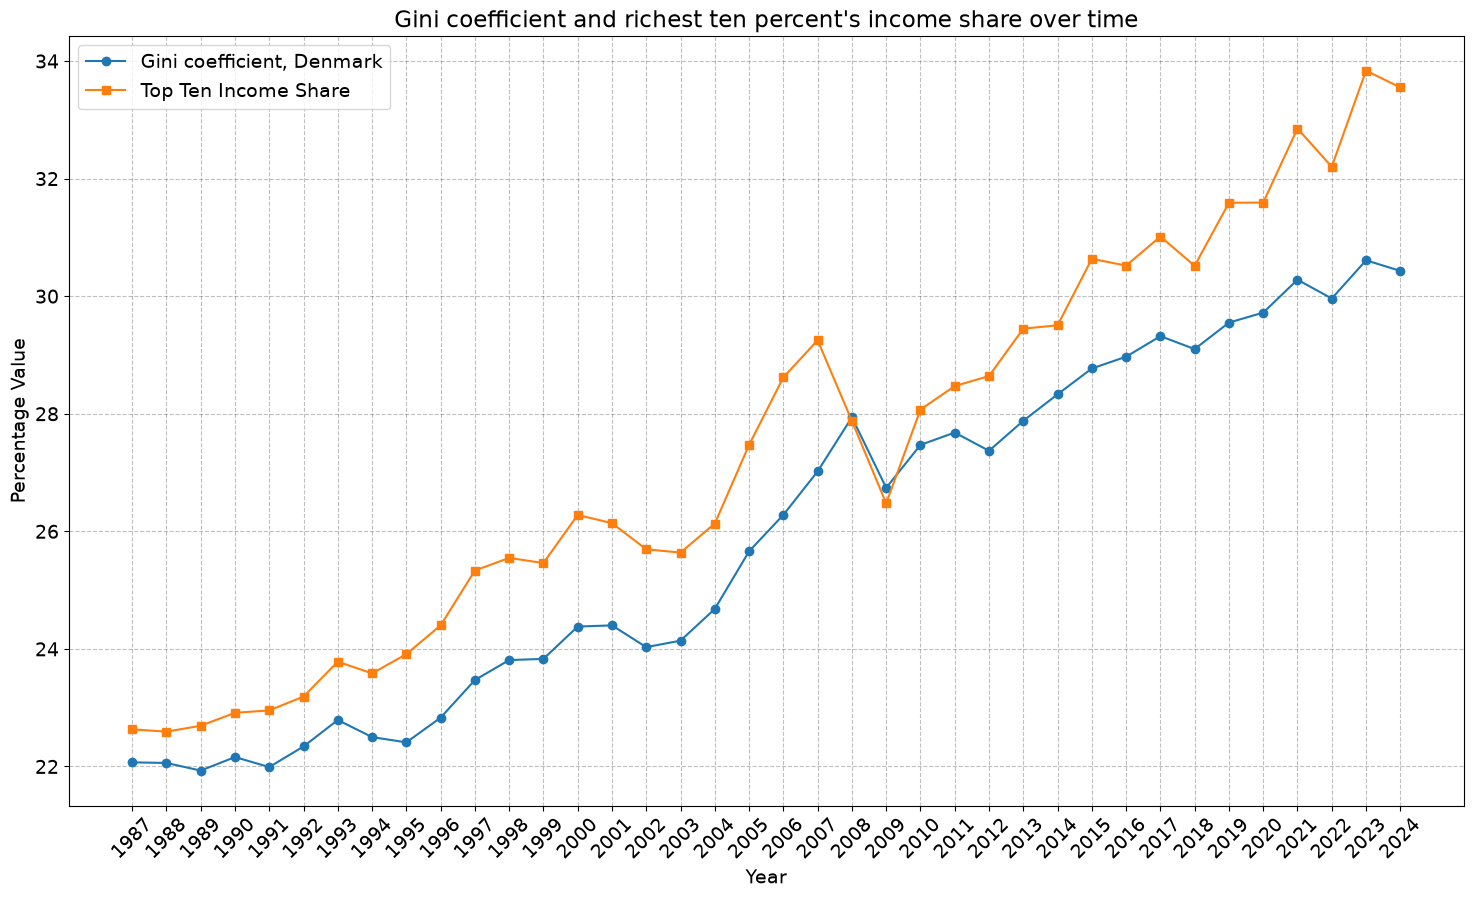

In [123]:
plt.figure(figsize=(18, 10))

plt.plot(GiniDenmark.iloc[:, 0], GiniDenmark.iloc[:, 1], marker='o', label='Gini coefficient, Denmark')
plt.plot(TopTenIncomeShare.iloc[:, 0], TopTenIncomeShare.iloc[:, 1], marker='s', label='Top Ten Income Share')

plt.xticks(GiniDenmark.iloc[:, 0][::1], rotation=45)
plt.xlabel("Year")
plt.ylabel("Percentage Value")
plt.title("Gini coefficient and richest ten percent's income share over time")
plt.legend()
plt.grid(True)
plt.show()

In [125]:
# Correlation

merged = pd.merge(GiniDenmark, TopTenIncomeShare, on="Year", how="inner")
correlation = merged["Gini coefficient, Denmark"].corr(merged["Top Ten Income Share"])
print(f"Correlation: {correlation:.4f}")

Correlation: 0.9806


### Describe how inequality in Denmark has developed since 1987. Do the two measures tell the same story? Compute the correlation between them over time.

Both measures show a clear upward trend: the Gini coefficient rises from ~22 (1987) to ~30.5 (2024), while the top 10% income share rises from ~22.5% to ~33.5%.

Key patterns:
* 1987-2003: slow, steady increase
* 2004-2008: sharp rise (likely capital income boom)
* 2008-2009: sharp drop (financial crisis)
* 2009-2024: renewed steady increase, peaking around 2023

**Do the two measures tell the same story?** 
\
They track each other closely, sharing the same overall shape and the same crisis dip, suggesting inequality is largely driven by changes at the very top of the distribution. The top 10% share appears to grow slightly faster than the Gini coefficient after ~2015, hinting that inequality is increasingly concentrated at the top rather than spread across the whole distribution.

**Correlation:**
\
A correlation of 0.98 confirms pattern: the two measures move almost identically over time.
This makes sense, since the Gini coefficient is sensitive to changes at the top of the distribution, so it's expected to track the top 10% income share closely. 